# Simple Trading Strategies: A Walk-Forward Comparison

This notebook compares four long-only strategies, and a hybrid that switches between them, on BTC-USD spot at four bar sizes (5m, 30m, 60m, 1d) with 10bps costs per side. Each strategy's parameters are re-fitted by grid search on a rolling training window and traded out-of-sample until the next re-fit.

**Strategies:** Momentum, Vol-adjusted Momentum, EWMA Trend Reversal, Donchian Breakout, Hybrid (best strategy and parameters at each re-fit)  
**Benchmark:** BTC-USD buy-and-hold  
**Statistical evaluation:** Block bootstrap Sharpe CIs, paired Sharpe difference tests, Deflated Sharpe Ratio (Bailey & López de Prado, 2014)

In [1]:
import sys, os
from pathlib import Path

# The notebook lives in notebooks/. Work from the repository root, because src.stats
# reads results/ with a path relative to it.
project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == 'Simple_trading_strats')
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

from src.data_binance import get_data_binance
from src.data import get_data_yf
from src.walkforward_hybrid import cost_bps
from src.stats import summary_table

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

TICKER = 'BTC-USD'
INTERVALS = ['5m', '30m', '60m', '1d']
LABELS = {
    'accurate':          'Momentum',
    'vol_adjusted':      'Vol-adjusted Momentum',
    'trend_reversal':    'EWMA Trend Reversal',
    'donchian_breakout': 'Donchian Breakout',
    'hybrid':            'Hybrid',
}

# 5m, 30m and 60m bars come from Binance, 1d bars from yfinance (as in the walk-forward scripts)
prices = {}
for interval in INTERVALS:
    raw = get_data_yf(interval) if interval == '1d' else get_data_binance(interval)
    df = raw[TICKER].copy()
    df.index = pd.to_datetime(df.index, utc=True)
    prices[interval] = df

print(f'Ticker: {TICKER}')
for interval, df in prices.items():
    print(f'{interval:>3} bars: {df.index[0].date()} to {df.index[-1].date()}, {len(df):,} bars')

1h Data already saved as parquet
1d Data already saved as csv
Ticker: BTC-USD
 5m bars: 2018-01-01 to 2026-09-30, 918,554 bars
30m bars: 2018-01-01 to 2026-09-30, 153,101 bars
60m bars: 2018-01-01 to 2026-09-30, 76,560 bars
 1d bars: 2018-01-01 to 2026-10-02, 3,197 bars


/Users/enriquecervero/Desktop/Simple_trading_strats/src/data.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_df = pd.read_csv(data_csv, index_col=[0, 1], parse_dates=True)


In [2]:
print('Strategies considered:')
print(list(LABELS.values()))

Strategies considered:
['Momentum', 'Vol-adjusted Momentum', 'EWMA Trend Reversal', 'Donchian Breakout', 'Hybrid']


## 1. Load walk-forward results

The backtests are not re-run here. A full grid search is repeated at every re-fit, so `python -m src.walkforward` and `python -m src.walkforward_hybrid` are run once and their per-trade results are saved to `results/`, which is what this notebook reads.

| Bar size | Data | Training window | Re-fit every | Min trades | Hybrid Sharpe gate |
|---|---|---|---|---|---|
| 5m | Binance | 90 days | 30 days | 20 | 3.5 |
| 30m | Binance | 180 days | 30 days | 20 | 3.0 |
| 60m | Binance | 365 days | 60 days | 20 | 2.0 |
| 1d | yfinance | 730 days | 60 days | 10 | 1.5 |

Parameters are selected by in-sample Sharpe among combinations with at least the minimum number of trades. At each re-fit the hybrid takes the strategy with the highest in-sample total return among those whose in-sample Sharpe clears the gate, and stays flat if none does. All runs use 10bps costs per side.

In [3]:
# Training window in bars: the first out-of-sample bar is prices.index[lookback]
LOOKBACK = {
    '5m':  90 * 24 * 60 // 5,
    '30m': 180 * 24 * 60 // 30,
    '60m': 365 * 24 * 60 // 60,
    '1d':  730,
}
BASE = ['accurate', 'vol_adjusted', 'trend_reversal', 'donchian_breakout']
RFR = 1.10

results = {}
for interval in INTERVALS:
    cum = pd.read_csv(os.path.join(RESULTS_DIR, f'hybrid_walkforward_cum_returns_{interval}.csv'),
                      index_col='exit_time', parse_dates=True)
    cum.index = pd.to_datetime(cum.index, utc=True)

    close = prices[interval]['Close']
    backtest_start, backtest_end = close.index[LOOKBACK[interval]], close.index[-1]

    # Strategy curves, indexed by trade exit time
    cum_returns = {LABELS[s]: cum[s].dropna() for s in BASE + ['hybrid']}
    cum_returns['Equal Weight'] = cum[BASE].ffill().fillna(1.0).mean(axis=1)

    # Align the benchmark to the backtest period
    # (the 1d figure in walkforward_hybrid.py has no BTC curve, so none is drawn here either)
    if interval != '1d':
        bench = close[backtest_start:backtest_end]
        cum_returns[TICKER] = (bench / bench.iloc[0]).resample('1D').last()

    bench_idx = pd.date_range(backtest_start, backtest_end, freq='1D')
    years = (bench_idx - bench_idx[0]) / pd.Timedelta(days=365.25)

    results[interval] = {
        'cum_returns': cum_returns,
        'constant_growth': pd.Series(RFR ** years, index=bench_idx),
    }
    print(f'{interval:>3} bars: backtest period {backtest_start.date()} to {backtest_end.date()}')

 5m bars: backtest period 2018-04-02 to 2026-09-30
30m bars: backtest period 2018-07-01 to 2026-09-30
60m bars: backtest period 2019-01-03 to 2026-09-30
 1d bars: backtest period 2020-01-01 to 2026-10-02


## 2. Cumulative returns

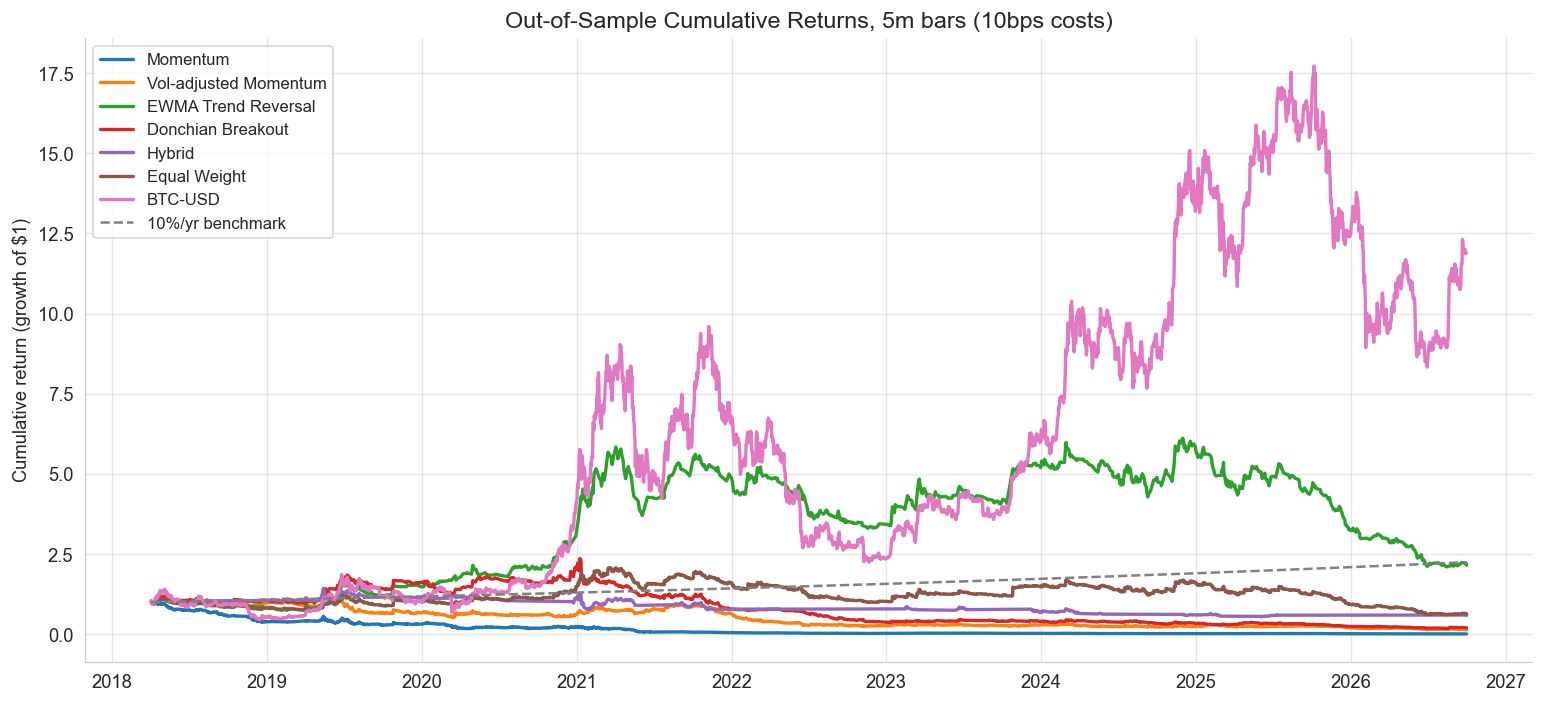

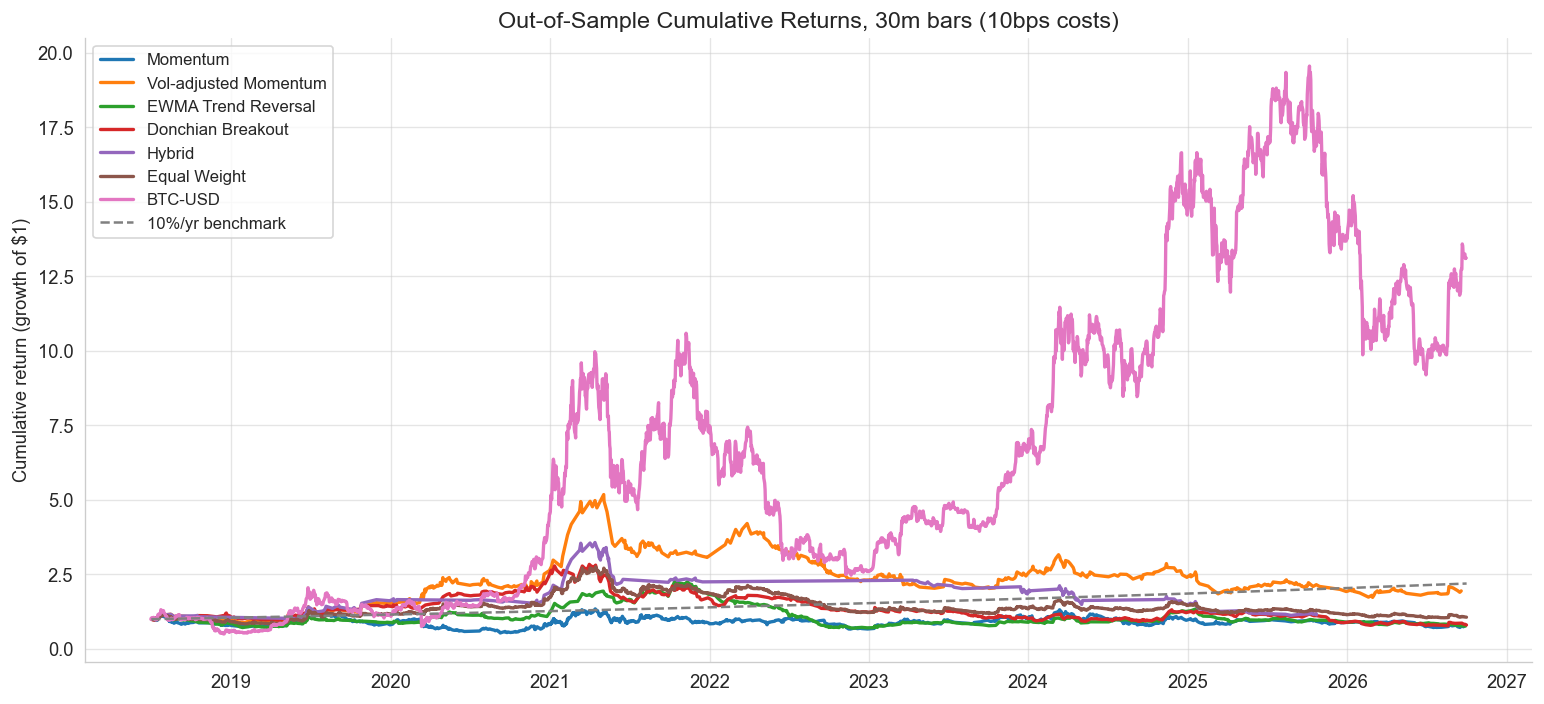

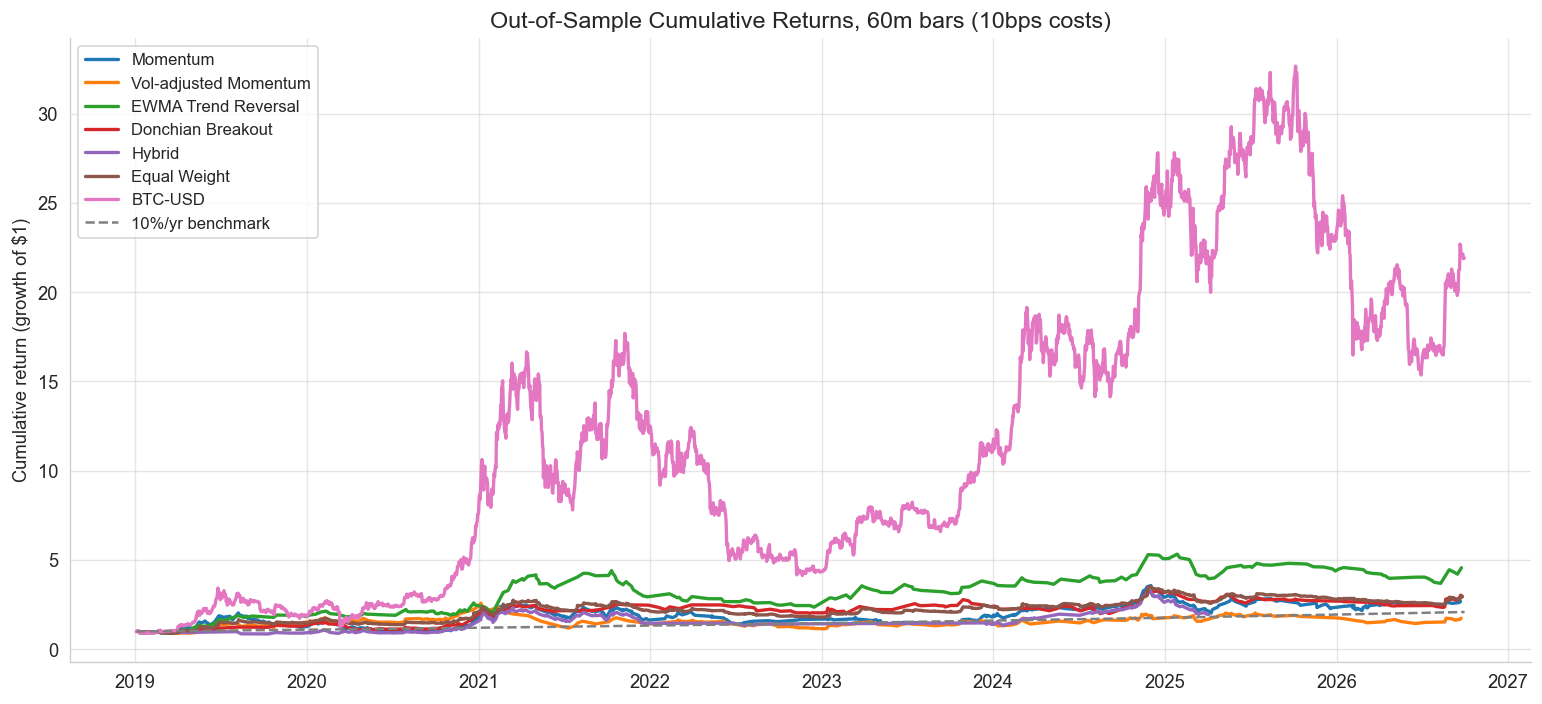

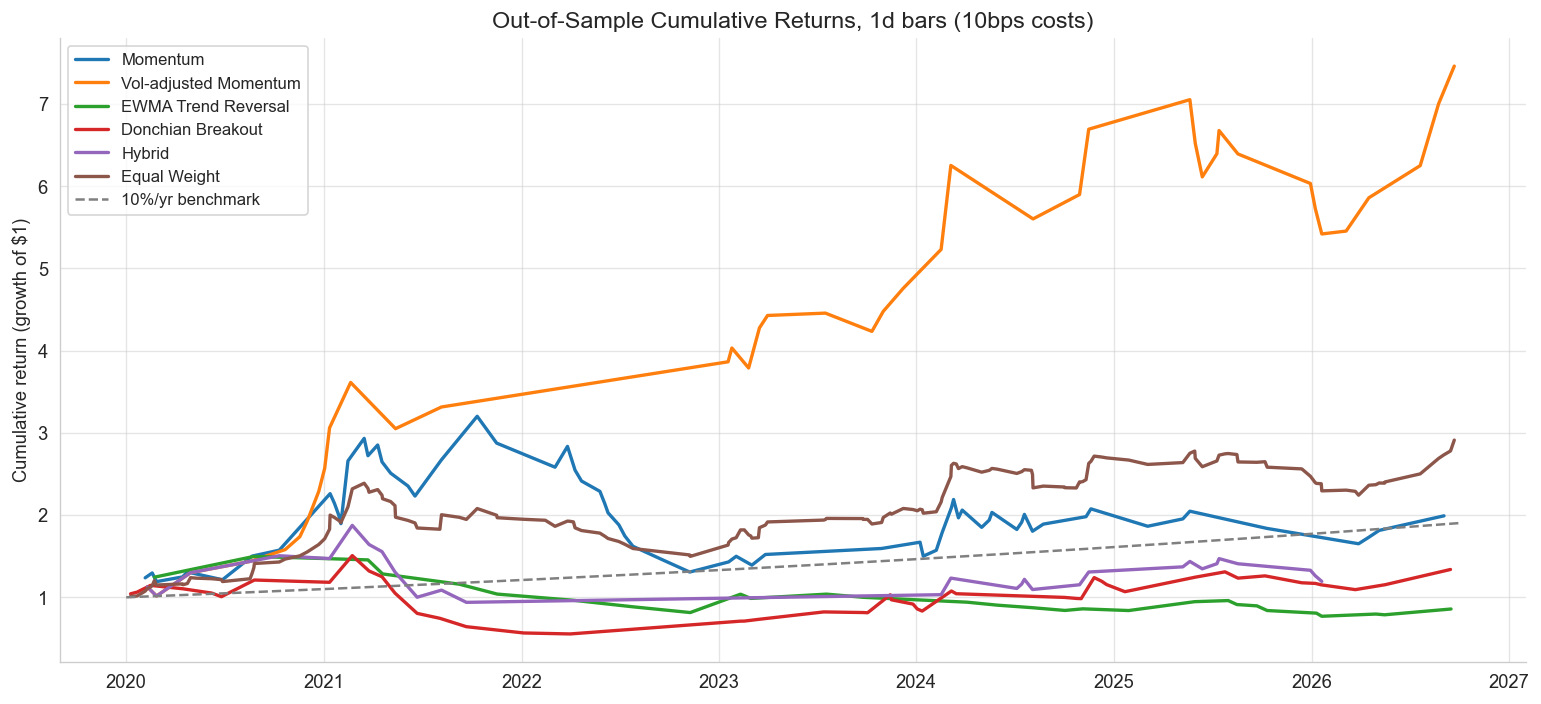

In [4]:
names = list(LABELS.values()) + ['Equal Weight', TICKER]
palette = dict(zip(names, sns.color_palette('tab10', n_colors=len(names))))

for interval in INTERVALS:
    fig, ax = plt.subplots(figsize=(13, 6))

    for name, curve in results[interval]['cum_returns'].items():
        ax.plot(curve.index, curve.values, label=name, color=palette[name], linestyle='-', linewidth=2)

    const = results[interval]['constant_growth']
    ax.plot(const.index, const.values, label=f'{int(round((RFR - 1) * 100))}%/yr benchmark',
            color='grey', linestyle='--', linewidth=1.5)

    ax.set_ylabel('Cumulative return (growth of $1)')
    ax.set_title(f'Out-of-Sample Cumulative Returns, {interval} bars ({cost_bps:g}bps costs)', fontsize=14)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(alpha=0.5)
    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'oos_backtest_comparison_{interval}.png'), dpi=150)
    plt.show()

## 3. Summary statistics

Per-trade returns are compounded by exit day into daily returns (zero on days without an exit) and annualised with 365 days. Bootstrap Sharpe confidence intervals (block bootstrap, B=10,000, block size=21 days) and the Deflated Sharpe Ratio (Bailey & López de Prado, 2014) correct for estimation noise and multiple testing. The number of trials in the DSR is the total number of grid combinations across the strategies at that bar size.

In [5]:
STRATEGIES = [TICKER, 'accurate', 'vol_adjusted', 'trend_reversal', 'donchian_breakout']

stats_tables, bootstrap_sharpes = {}, {}
for interval in INTERVALS:
    print(f'Computing {interval}...')
    stats_tables[interval], bootstrap_sharpes[interval] = summary_table(
        strategies=STRATEGIES, interval=interval, lookback=LOOKBACK[interval], benchmark=TICKER, n_boot=10000
    )

stats_table = (pd.concat(stats_tables, names=['Interval', 'Strategy'])
                 .rename(index=LABELS, level='Strategy')
                 .astype(float))

display_cols = [
    'Annual Return', 'Annual Vol', 'Sharpe', 'Sharpe CI lower', 'Sharpe CI upper',
    'Max Drawdown', 'Calmar', 'DSR'
]
stats_table[display_cols].round(3)

Computing 5m...
Computing 30m...
Computing 60m...
Computing 1d...


/Users/enriquecervero/Desktop/Simple_trading_strats/src/data.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_df = pd.read_csv(data_csv, index_col=[0, 1], parse_dates=True)


Annual Return  Annual Vol  Sharpe  \
Interval Strategy                                                   
5m       BTC-USD                        0.343       0.619   0.790   
         Momentum                      -0.416       0.372  -1.258   
         Vol-adjusted Momentum         -0.205       0.305  -0.600   
         EWMA Trend Reversal            0.095       0.362   0.419   
         Donchian Breakout             -0.172       0.319  -0.438   
30m      BTC-USD                        0.365       0.616   0.818   
         Momentum                      -0.035       0.386   0.097   
         Vol-adjusted Momentum          0.084       0.322   0.409   
         EWMA Trend Reversal           -0.032       0.329   0.055   
         Donchian Breakout             -0.026       0.335   0.081   
60m      BTC-USD                        0.487       0.614   0.959   
         Momentum                       0.136       0.408   0.505   
         Vol-adjusted Momentum          0.074       0.310   0.388   
         EWMA Trend Reversal            0.217       0.382   0.681   
         Donchian Breakout              0.149       0.313   0.589   
1d       BTC-USD                        0.442       0.595   0.918   
         Momentum                       0.107       0.365   0.442   
         Vol-adjusted Momentum          0.346       0.270   1.228   
         EWMA Trend Reversal           -0.022       0.203  -0.018   
         Donchian Breakout              0.044       0.317   0.283   

                                Sharpe CI lower  Sharpe CI upper  \
Interval Strategy                                                  
5m       BTC-USD                          0.096            1.505   
         Momentum                        -1.975           -0.570   
         Vol-adjusted Momentum           -1.279            0.052   
         EWMA Trend Reversal             -0.301            1.036   
         Donchian Breakout               -1.149            0.195   
30m      BTC-USD                          0.115            1.535   
         Momentum                        -0.587            0.734   
         Vol-adjusted Momentum           -0.268            1.074   
         EWMA Trend Reversal             -0.695            0.681   
         Donchian Breakout               -0.614            0.703   
60m      BTC-USD                          0.240            1.713   
         Momentum                        -0.158            1.104   
         Vol-adjusted Momentum           -0.327            1.110   
         EWMA Trend Reversal              0.028            1.182   
         Donchian Breakout               -0.087            1.128   
1d       BTC-USD                          0.134            1.721   
         Momentum                        -0.306            1.016   
         Vol-adjusted Momentum            0.559            1.777   
         EWMA Trend Reversal             -1.016            0.627   
         Donchian Breakout               -0.516            0.901   

                                Max Drawdown  Calmar    DSR  
Interval Strategy                                            
5m       BTC-USD                      -0.766   0.448  0.170  
         Momentum                     -0.990  -0.420  0.000  
         Vol-adjusted Momentum        -0.874  -0.235  0.000  
         EWMA Trend Reversal          -0.656   0.144  0.026  
         Donchian Breakout            -0.922  -0.187  0.000  
30m      BTC-USD                      -0.766   0.477  0.200  
         Momentum                     -0.581  -0.060  0.002  
         Vol-adjusted Momentum        -0.666   0.126  0.024  
         EWMA Trend Reversal          -0.691  -0.046  0.001  
         Donchian Breakout            -0.725  -0.036  0.002  
60m      BTC-USD                      -0.766   0.636  0.296  
         Momentum                     -0.516   0.264  0.047  
         Vol-adjusted Momentum        -0.555   0.134  0.018  
         EWMA Trend Reversal          -0.465   0.466  0.206  
         Donchian Breako

In [6]:
# Pairwise Sharpe difference tests vs BTC-USD
diff_cols = ['Mean Sharpe diff', 'Sharpe diff CI lower', 'Sharpe diff CI upper', 'Pct wins vs Benchmark']
stats_table[diff_cols].round(3)

Mean Sharpe diff  Sharpe diff CI lower  \
Interval Strategy                                                        
5m       BTC-USD                           0.000                   NaN   
         Momentum                         -2.048                -2.614   
         Vol-adjusted Momentum            -1.397                -2.077   
         EWMA Trend Reversal              -0.392                -1.013   
         Donchian Breakout                -1.245                -1.920   
30m      BTC-USD                           0.000                   NaN   
         Momentum                         -0.731                -1.311   
         Vol-adjusted Momentum            -0.417                -1.097   
         EWMA Trend Reversal              -0.786                -1.502   
         Donchian Breakout                -0.756                -1.397   
60m      BTC-USD                           0.000                   NaN   
         Momentum                         -0.464                -1.050   
         Vol-adjusted Momentum            -0.572                -1.241   
         EWMA Trend Reversal              -0.296                -1.019   
         Donchian Breakout                -0.389                -1.093   
1d       BTC-USD                           0.000                   NaN   
         Momentum                         -0.506                -1.326   
         Vol-adjusted Momentum             0.291                -0.425   
         EWMA Trend Reversal              -1.002                -2.214   
         Donchian Breakout                -0.661                -1.712   

                                Sharpe diff CI upper  Pct wins vs Benchmark  
Interval Strategy                                                            
5m       BTC-USD                                 NaN                    NaN  
         Momentum                             -1.482                  0.000  
         Vol-adjusted Momentum                -0.726                  0.000  
         EWMA Trend Reversal                   0.207                  0.102  
         Donchian Breakout                    -0.584                  0.000  
30m      BTC-USD                                 NaN                    NaN  
         Momentum                             -0.164                  0.006  
         Vol-adjusted Momentum                 0.264                  0.112  
         EWMA Trend Reversal                  -0.093                  0.011  
         Donchian Breakout                    -0.112                  0.010  
60m      BTC-USD                                 NaN                    NaN  
         Momentum                              0.108                  0.057  
         Vol-adjusted Momentum                 0.081                  0.043  
         EWMA Trend Reversal                   0.388                  0.200  
         Donchian Breakout                     0.301                  0.140  
1d       BTC-USD                                 NaN                    NaN  
         Momentum                              0.280                  0.105  
         Vol-adjusted Momentum                 0.987                  0.795  
         EWMA Trend Reversal                   0.085                  0.036  
         Donchian Breakout                     0.301                  0.091

## 4. Bootstrap Sharpe distributions

Overlapping density plots show how much uncertainty exists in each strategy's Sharpe estimate. Wide overlap means the strategies are statistically indistinguishable over the out-of-sample period.

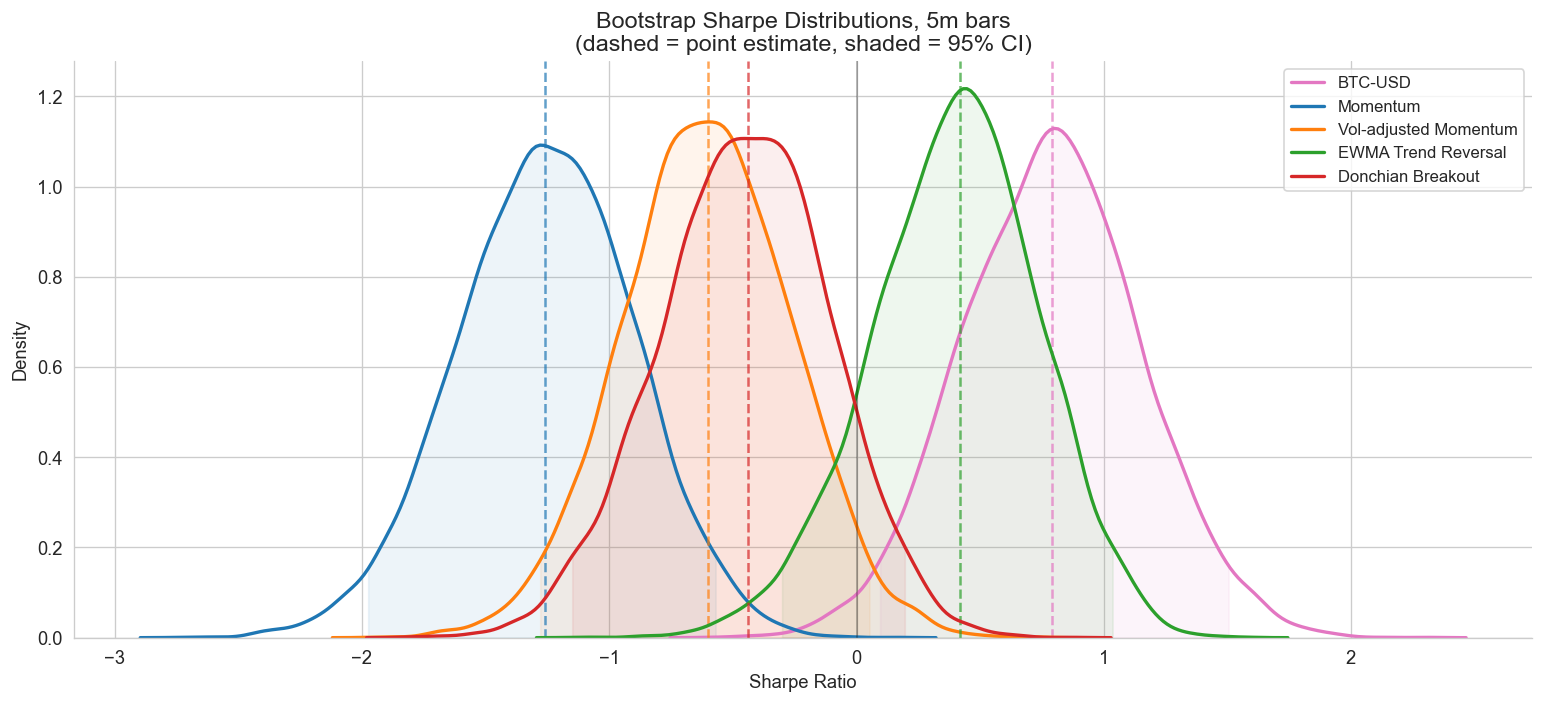

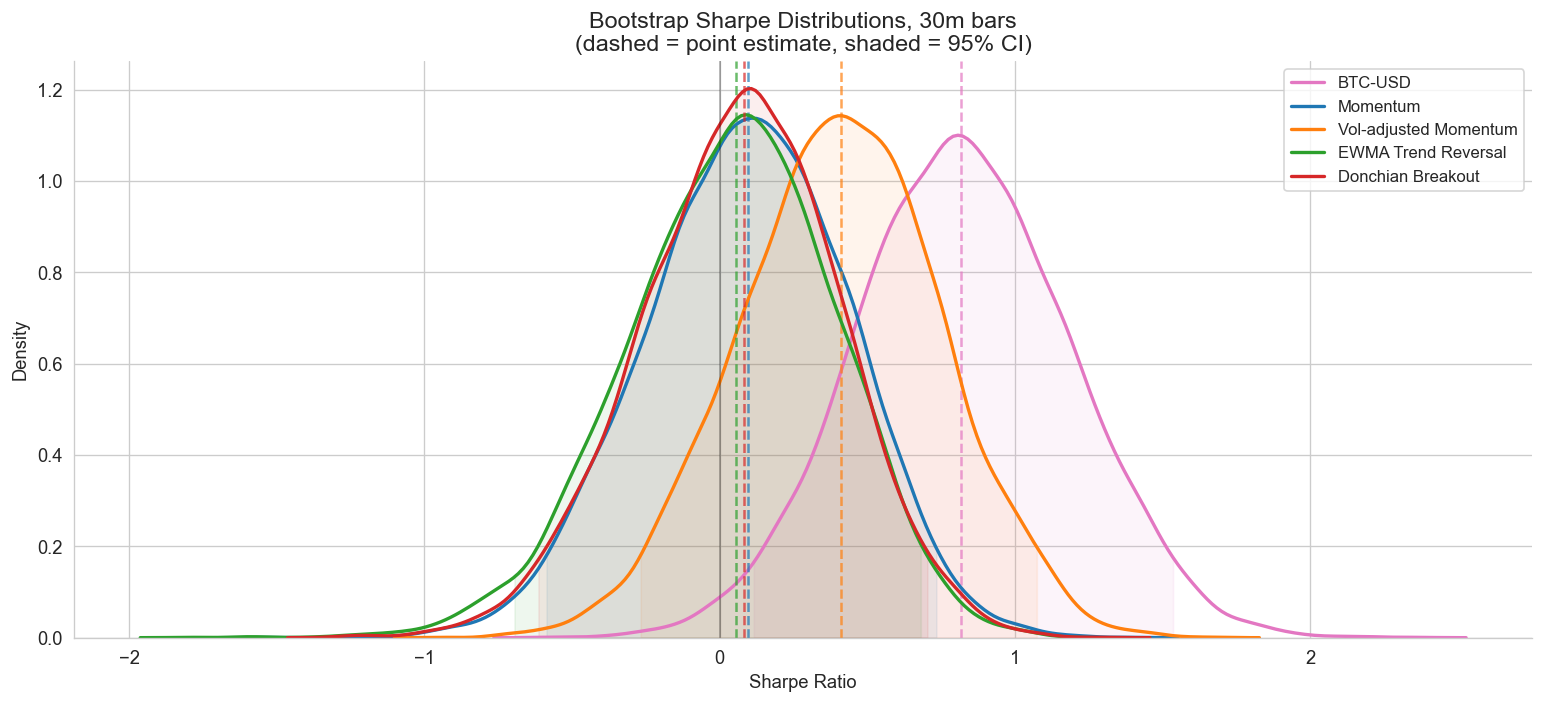

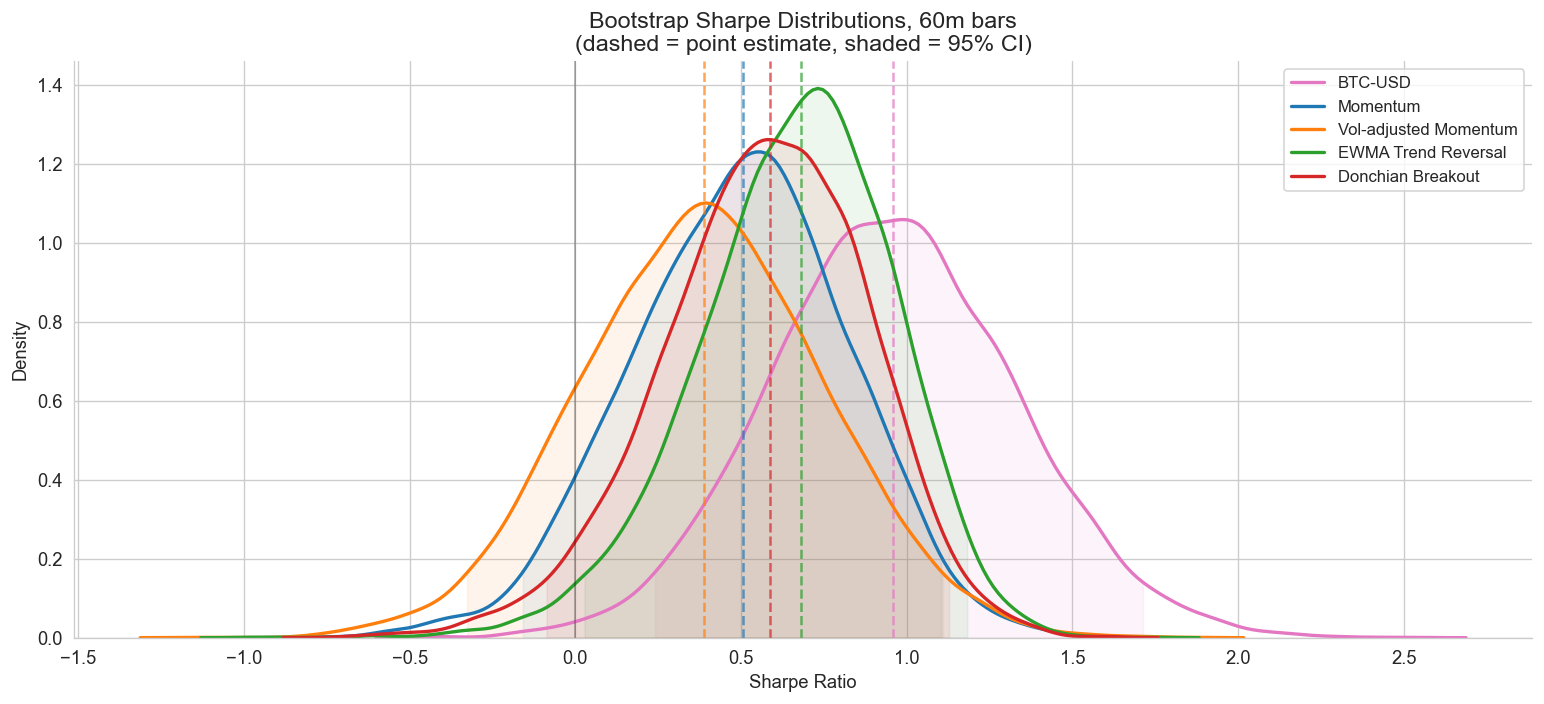

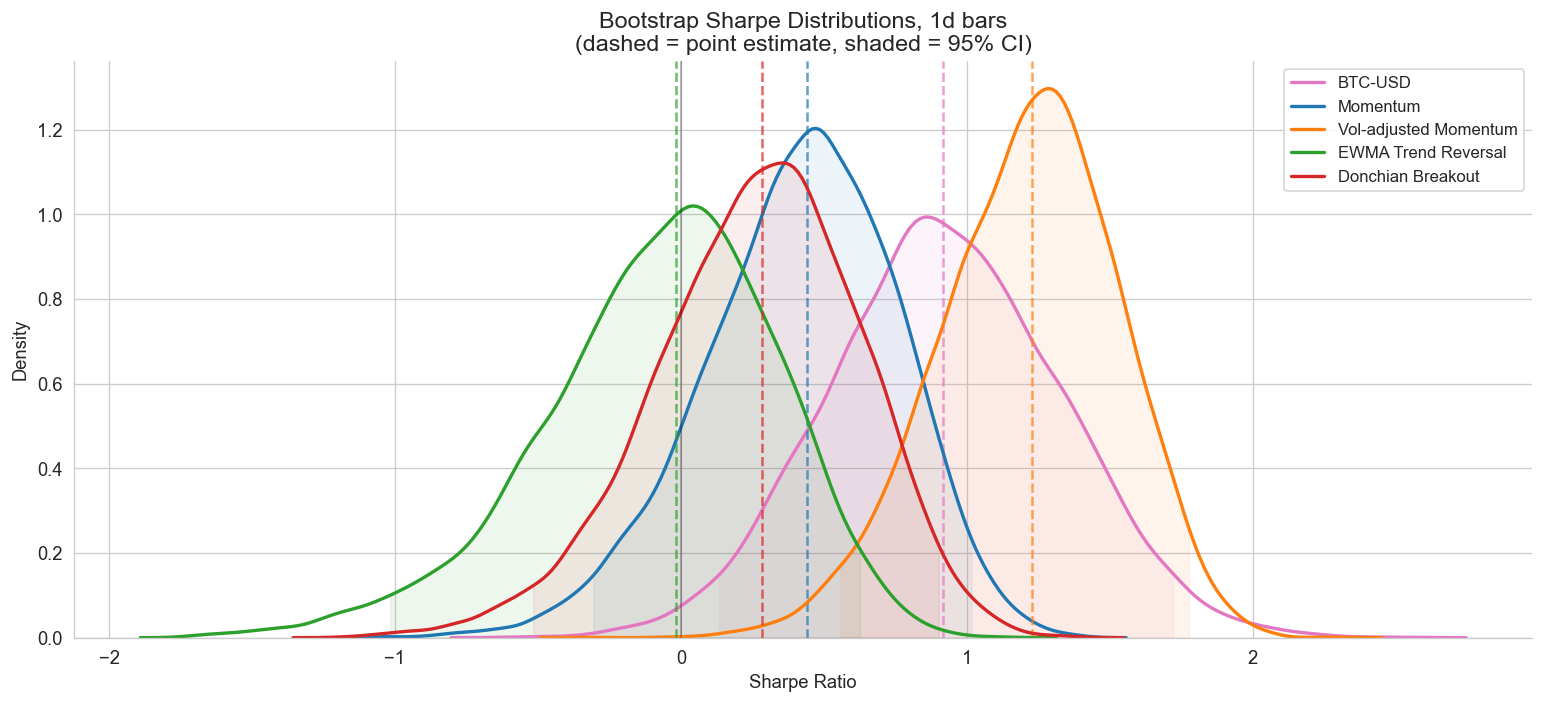

In [7]:
for interval in INTERVALS:
    point_sharpes = stats_table.loc[interval, 'Sharpe']

    fig, ax = plt.subplots(figsize=(13, 6))

    for strat, sharpes in bootstrap_sharpes[interval].items():
        name = LABELS.get(strat, strat)
        color = palette[name]
        sns.kdeplot(sharpes, ax=ax, color=color, linewidth=2, label=name)

        # Dashed vertical line at point estimate
        ax.axvline(point_sharpes[name], color=color, linewidth=1.5, linestyle='--', alpha=0.7)

        # Shade 95% CI
        ci_lo, ci_hi = np.percentile(sharpes, [2.5, 97.5])
        kde = gaussian_kde(sharpes)
        x = np.linspace(ci_lo, ci_hi, 200)
        ax.fill_between(x, kde(x), alpha=0.08, color=color)

    ax.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.3)
    ax.set_xlabel('Sharpe Ratio')
    ax.set_ylabel('Density')
    ax.set_title(f'Bootstrap Sharpe Distributions, {interval} bars\n(dashed = point estimate, shaded = 95% CI)', fontsize=14)
    ax.legend(fontsize=10)
    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'bootstrap_sharpe_comparison_{interval}.png'), dpi=150)
    plt.show()

## 5. Key findings

**1. No strategy beats buy-and-hold BTC with statistical support.** Of the 16 strategy and bar-size combinations, 15 have a lower Sharpe than BTC-USD over the same period. The bootstrap CI of the Sharpe difference lies entirely below zero for 6 of them (Momentum, Vol-adjusted Momentum and Donchian Breakout on 5m; Momentum, EWMA Trend Reversal and Donchian Breakout on 30m) and straddles zero for the other 10. None lies above zero.

**2. Performance deteriorates on shorter bars.** The average strategy Sharpe is -0.47 on 5m, 0.16 on 30m, 0.54 on 60m and 0.48 on 1d. On 5m bars, three of the four strategies lose money (-17% to -42% a year) with drawdowns of 87% to 99%, and Momentum's Sharpe CI (-1.98 to -0.57) is entirely negative. This is consistent with the 10bps per-side cost weighing most on the strategies that trade most often, but the notebook has no trade counts to confirm it.

**3. Vol-adjusted Momentum on 1d bars is the only result that stands out.** Its Sharpe is 1.23 (CI 0.56 to 1.78) against 0.92 for BTC-USD, with less than half the volatility (27% vs 60%) and a max drawdown of -23% against -77%, giving a Calmar of 1.50 against 0.58. Its annual return is still lower (34.6% vs 44.2%), the CI of its Sharpe difference straddles zero (-0.43 to 0.99), and it is one favourable result out of 16.

**4. No strategy is consistently best across bar sizes.** EWMA Trend Reversal has the highest Sharpe on 5m (0.42) and 60m (0.68) but the lowest on 30m (0.06) and 1d (-0.02). Vol-adjusted Momentum is best on 30m (0.41) and 1d (1.23) but weakest on 60m (0.39). Picking the in-sample winner does not fix this: the Hybrid, which appears only in the figures, finishes below the best single strategy on 5m, 60m and 1d bars.

**5. Nothing clears the multiple-testing bar.** Every DSR is below 0.95. The two highest are Vol-adjusted Momentum on 1d (0.866) and EWMA Trend Reversal on 60m (0.206); every other strategy is below 0.10. These two are also the only strategies whose Sharpe CI excludes zero on the positive side.

*Caveats.* The out-of-sample periods start on different dates (2018-04, 2018-07, 2019-01 and 2020-01), so comparisons across bar sizes are not like-for-like. A trade's whole return is booked on its exit day, so drawdowns are understated for trades that last several days. The DSR shown for BTC-USD uses the strategies' grid count and is not a test of buy-and-hold.